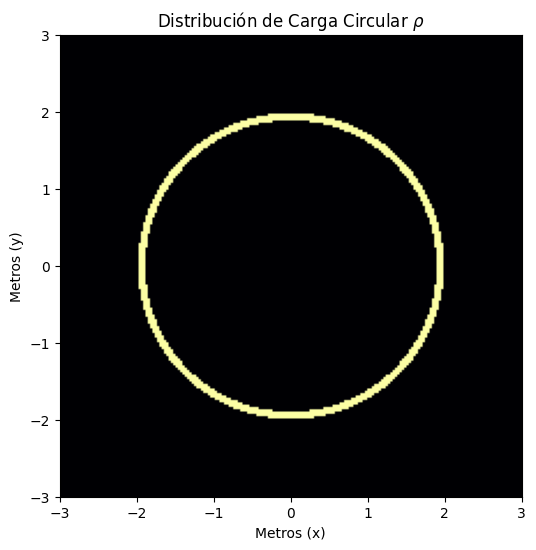

In [57]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt

# --- A. CONFIGURACIÓN DEL ESPACIO ---
metros = 5 # Factor de escala espacial
Lx, Ly = 1.2 * metros, 1.2 * metros # Dimensiones físicas del dominio (metros)

# Tamaño y resolución de la malla
Mx, My = 200, 200

# Diferenciales de distancia espacial (paso de la malla)
dx, dy = Lx / (Mx - 1), Ly / (My - 1) 
h = dx
e_0 = 8.8541878128e-12  # Permitividad del vacío (F/m)

# Creación de los arreglos espaciales 1D
x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)

# Generación de la malla bidimensional
X, Y = np.meshgrid(x, y)

# Matriz de distancias radiales respecto al origen
R = np.sqrt(X**2 + Y**2)

# --- B. DEFINICIÓN DE LA DENSIDAD DE CARGA ---

# Caso Anillo: Definimos un radio exterior e interior
r_out = 2.0 # metros
r_in = 1.9  # metros

# Máscara booleana para filtrar solo la región del anillo
mask_ring = (R <= r_out) & (R >= r_in) 

# Inicializamos la matriz de densidad de carga rho con ceros
rho = np.zeros((My, Mx))

# Valor arbitrario de la carga
Q = 1e-9 # Coulomb

# Asignamos la carga Q únicamente a la región definida por el anillo
rho[mask_ring] = Q

# --- Visualización de la distribución de carga ---
plt.figure(figsize=(6,6))
plt.title(r"Distribución de Carga Circular $\rho$")
# Usamos 'extent' para mapear los píxeles a las dimensiones físicas reales
plt.imshow(rho, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='inferno')
plt.xlabel('Metros (x)')
plt.ylabel('Metros (y)')
plt.grid(False) # Retiramos la rejilla para mayor claridad visual
plt.show()

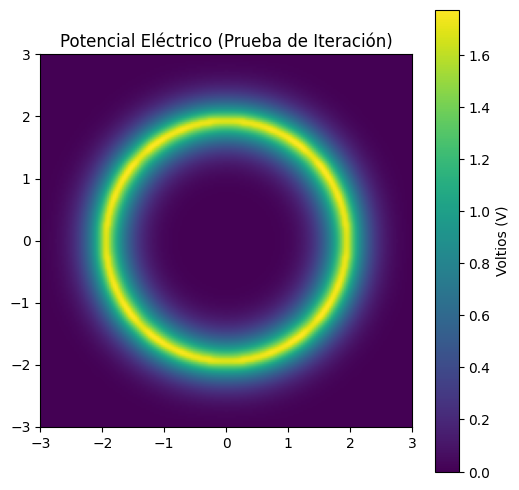

In [58]:
# --- C. DISCRETIZACIÓN Y SOLUCIÓN INICIAL ---

# Inicializamos la matriz del potencial en cero
phi = np.zeros((Mx, My))

# Aplicamos diferencias finitas iterando de forma vectorizada.
# Esto es computacionalmente más eficiente que utilizar ciclos 'for' anidados.
for _ in range(400):
    phi[1:-1,1:-1] = 0.25 * (phi[1:-1,2:] + phi[1:-1,:-2] + 
                             phi[2:,1:-1] + phi[:-2,1:-1] + 
                             (h**2 * rho[1:-1,1:-1]) / e_0)

# Visualización del avance preliminar
fig, ax = plt.subplots(1, 1, figsize=(6,6))
p = ax.imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin="lower", cmap="viridis")
ax.set_title("Potencial Eléctrico (Prueba de Iteración)")
plt.colorbar(p, ax=ax, label="Voltios (V)")
plt.show()

In [59]:
# --- D. MÉTODO ITERATIVO VECTORIZADO CON CONVERGENCIA ---
tolerancia = 1e-5
error = 1.0
i = 0
max_i = 10000

while error > tolerancia and i < max_i:
    # Guardamos el estado anterior para calcular el error
    phi_old = phi.copy()

    phi[1:-1,1:-1] = 0.25 * (phi[1:-1,2:] + phi[1:-1,:-2] + 
                             phi[2:,1:-1] + phi[:-2,1:-1] + 
                             (h**2 * rho[1:-1,1:-1]) / e_0)

    # Calculamos la convergencia mediante la diferencia máxima absoluta
    error = np.max(np.abs(phi - phi_old))
    i += 1
    
print(f"Método Vectorizado Simple: Convergencia en {i} iteraciones.")
print(f"Error acumulado final: {error:.2e}")

# Nota: El método anterior es estable pero converge lentamente. 
# Procederemos a optimizarlo implementando el método SOR.

Método Vectorizado Simple: Convergencia en 10000 iteraciones.
Error acumulado final: 4.99e-04


In [60]:
# --- E. OPTIMIZACIÓN: MÉTODO SOR CON ESQUEMA ROJO-NEGRO ---

# Factor de relajación óptimo para el método SOR
omega = 1.9
tolerancia = 1e-5
error = 1.0
iteraciones = 0
max_iter = 10000

# Se crea una matriz de coordenadas espaciales I x J
I, J = np.indices(phi.shape)

# Se generan máscaras booleanas para implementar un esquema tipo "tablero de ajedrez" (rojo-negro).
# Esto evita el sobrelapamiento de datos y permite vectorizar el método SOR.
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True # Protegemos los bordes asegurando la condición (0V)

mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error > tolerancia and iteraciones < max_iter:
    phi_old = phi.copy()
    
    # 1. Actualización de las casillas ROJAS
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho[1:-1, 1:-1] / e_0))
    
    # Aplicamos la fórmula de aceleración SOR solo a la máscara roja
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    
    # 2. Actualización de las casillas NEGRAS
    # Se recalculan los promedios incorporando los valores frescos de las casillas rojas
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho[1:-1, 1:-1] / e_0))
    
    # Aplicamos SOR a la máscara negra
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    # Se mide el error y se aumenta el contador de iteración
    error = np.max(np.abs(phi - phi_old))
    iteraciones += 1

print(f"Método SOR (Rojo-Negro): Convergencia en {iteraciones} iteraciones.")
print(f"Error acumulado final: {error:.2e}")

Método SOR (Rojo-Negro): Convergencia en 1570 iteraciones.
Error acumulado final: 9.96e-06


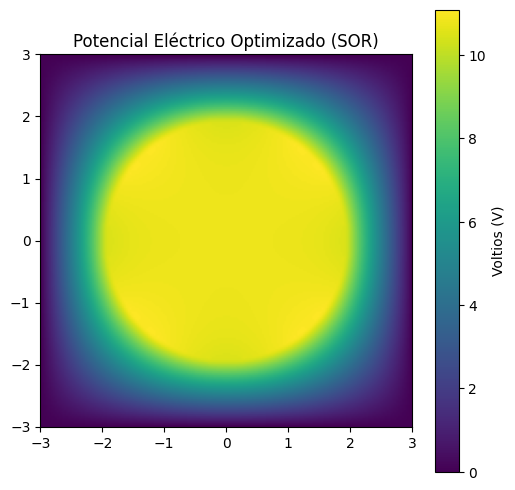

In [61]:
# --- Visualización del Potencial obtenido con SOR ---
fig, ax = plt.subplots(1, 1, figsize=(6,6))
p = ax.imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin="lower", cmap="viridis")
ax.set_title("Potencial Eléctrico Optimizado (SOR)")
plt.colorbar(p, ax=ax, label="Voltios (V)")
plt.show()

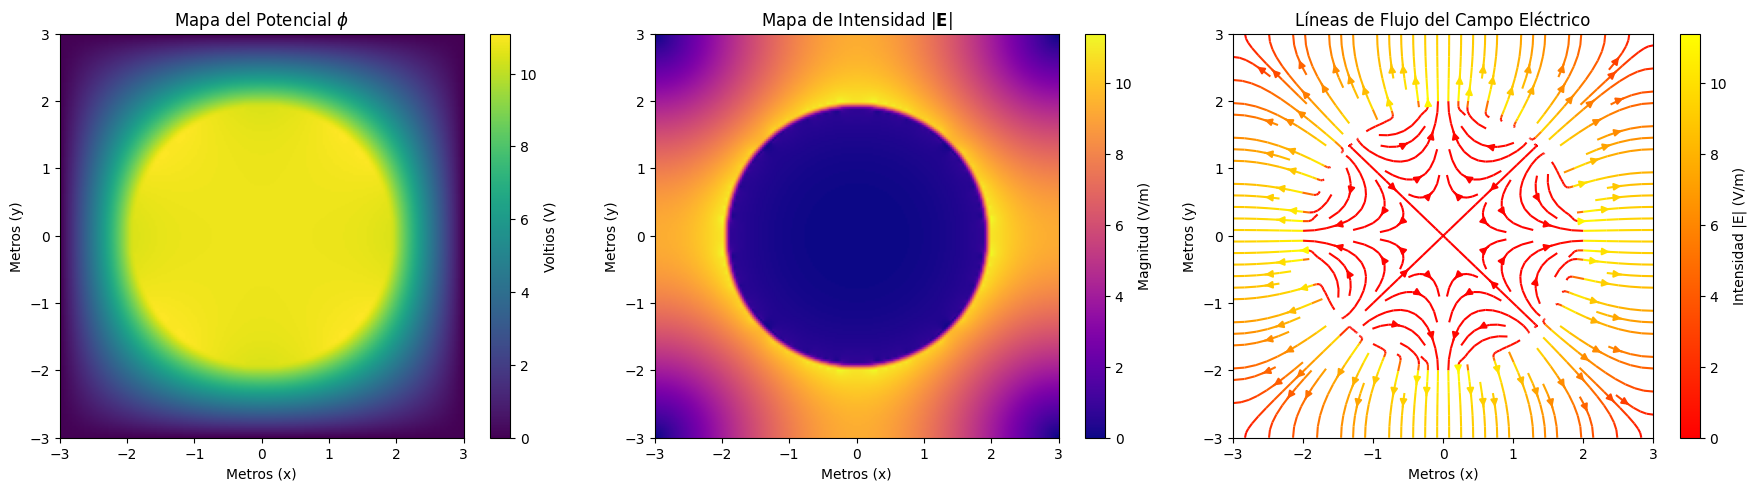

In [62]:
# --- F. CÁLCULO Y VISUALIZACIÓN DEL CAMPO ELÉCTRICO ---

# El campo eléctrico se define como el gradiente negativo del potencial escalar
Ey, Ex = np.gradient(-phi, dy, dx)

# Cálculo de la magnitud del campo eléctrico
E_mag = np.sqrt(Ex**2 + Ey**2)

# Se crea una figura con 3 subgráficos (1 fila, 3 columnas)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mapa del Potencial Escalar
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Panel 2: Mapa de Intensidad del Campo Eléctrico
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma')
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='Magnitud (V/m)')

# Panel 3: Líneas de Flujo del Campo Eléctrico
# Se pasa la magnitud del campo eléctrico como mapa de color para mejor visualización
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.2, linewidth=1.5)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()

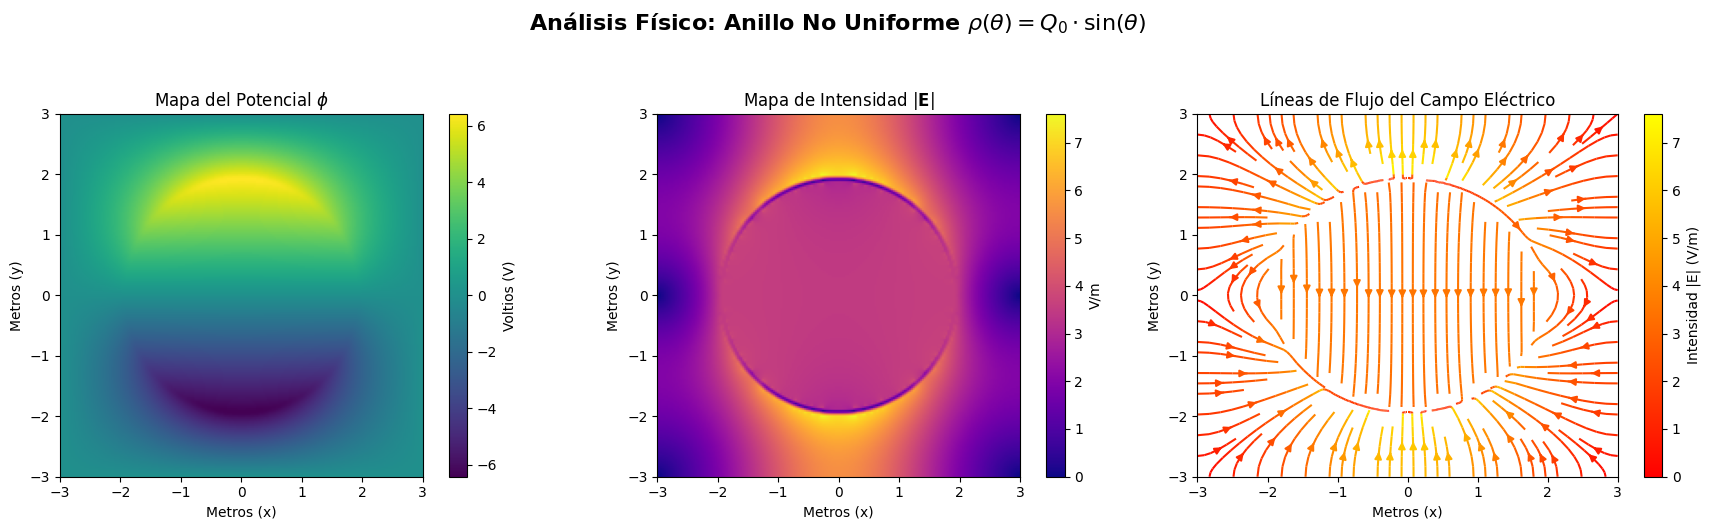

In [63]:
# Anillo de densidad no uniforme
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuración de la Malla ---
metros = 5 
Lx, Ly = 1.2 * metros, 1.2 * metros 
Mx, My = 200, 200 
dx, dy = Lx / (Mx - 1), Ly / (My - 1) 
h = dx
e_0 = 8.8541878128e-12

x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
X, Y = np.meshgrid(x, y)

# Geometría Anular + Densidad Angular Variable
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X) # Calculamos el ángulo polar theta para cada punto

r_out = 2.0 
r_in = 1.9  
mask_ring = (R <= r_out) & (R >= r_in) 

rho_variable = np.zeros((My, Mx))
Q0 = 1e-9    # Constante de magnitud de carga

# Asignamos la carga SOLO dentro del anillo, pero variando según el seno del ángulo
rho_variable[mask_ring] = Q0 * np.sin(Theta[mask_ring])

# Resolución Numérica SOR
phi = np.zeros((Mx, My))
omega = 1.9
tolerancia = 1e-5
error_sor = 1.0
iteraciones_sor = 0

I, J = np.indices(phi.shape)
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True 
mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < 10000:
    phi_old = phi.copy()
    
    # Actualización ROJAS
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_variable[1:-1, 1:-1] / e_0))
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    
    # Actualización NEGRAS
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_variable[1:-1, 1:-1] / e_0))
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    error_sor = np.max(np.abs(phi - phi_old))
    iteraciones_sor += 1

# Cálculo del Campo Vectorial
Ey, Ex = np.gradient(-phi, dy, dx)
E_mag = np.sqrt(Ex**2 + Ey**2)

# Visualización
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r"Análisis Físico: Anillo No Uniforme $\rho(\theta) = Q_{0} \cdot \sin(\theta)$", 
             fontsize=16, fontweight='bold', y=1.05)

# Panel 1: Mapa del potencial escalar ('seismic' para ver positivo/negativo)
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Panel 2: Mapa de intensidad de la magnitud del campo
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma')
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='V/m')

# Panel 3: Líneas de flujo del campo eléctrico
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.2, linewidth=1.5)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()

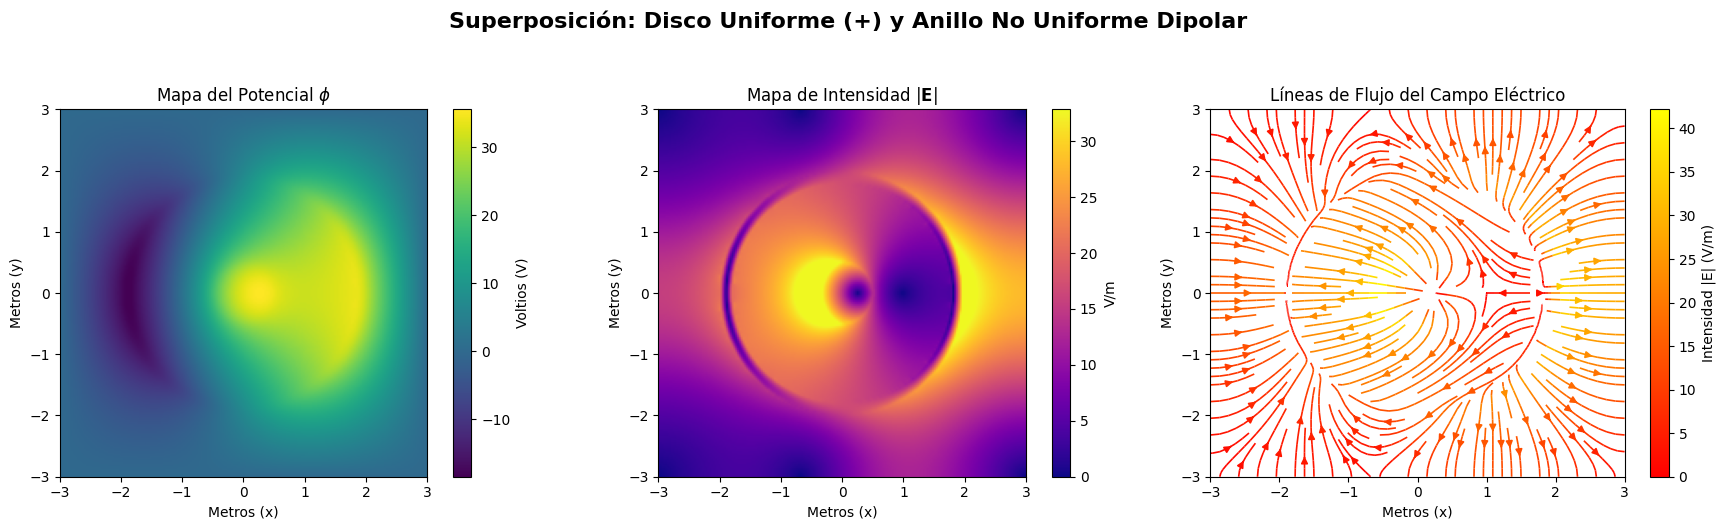

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de la Malla
metros = 5 
Lx, Ly = 1.2 * metros, 1.2 * metros 
Mx, My = 200, 200 
dx, dy = Lx / (Mx - 1), Ly / (My - 1) 
h = dx
e_0 = 8.8541878128e-12

x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X) # Ángulo polar para la densidad variable

# Superposición de Densidades en rho_combinada
rho_combinada = np.zeros((My, Mx))
Q0 = 1e-9    # Constante de magnitud de carga base

# Geometría A: Disco Central (Carga Uniforme Positiva)
radio_disco = 0.5
mask_disco = (R <= radio_disco)
rho_combinada[mask_disco] = Q0

# Geometría B: Anillo Exterior (Carga No Uniforme, Dipolo Horizontal)
r_out = 2.0 
r_in = 1.8  
mask_anillo = (R <= r_out) & (R >= r_in) 
# Usamos el doble de carga (2 * Q0) multiplicada por el coseno para exagerar el efecto
rho_combinada[mask_anillo] = 2 * Q0 * np.cos(Theta[mask_anillo])

# Resolución Numérica (Método SOR Vectorizado)
phi = np.zeros((Mx, My))
omega = 1.9
tolerancia = 1e-5
error_sor = 1.0
iteraciones_sor = 0

I, J = np.indices(phi.shape)
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True 
mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < 10000:
    phi_old = phi.copy()
    
    # Actualización ROJAS
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_combinada[1:-1, 1:-1] / e_0))
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    
    # Actualización NEGRAS
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_combinada[1:-1, 1:-1] / e_0))
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    error_sor = np.max(np.abs(phi - phi_old))
    iteraciones_sor += 1

# Cálculo del Campo Vectorial
Ey, Ex = np.gradient(-phi, dy, dx)
E_mag = np.sqrt(Ex**2 + Ey**2)

# Visualización (Formato de 3 Paneles)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r"Superposición: Disco Uniforme (+) y Anillo No Uniforme Dipolar", 
             fontsize=16, fontweight='bold', y=1.05)

# Panel 1: Mapa del potencial escalar
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Panel 2: Mapa de intensidad de la magnitud del campo
# Usamos vmax para evitar que el brillo del centro sature los detalles del anillo
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma', vmax=np.percentile(E_mag, 98))
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='V/m')

# Panel 3: Líneas de flujo del campo eléctrico
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.5, linewidth=1.2)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()

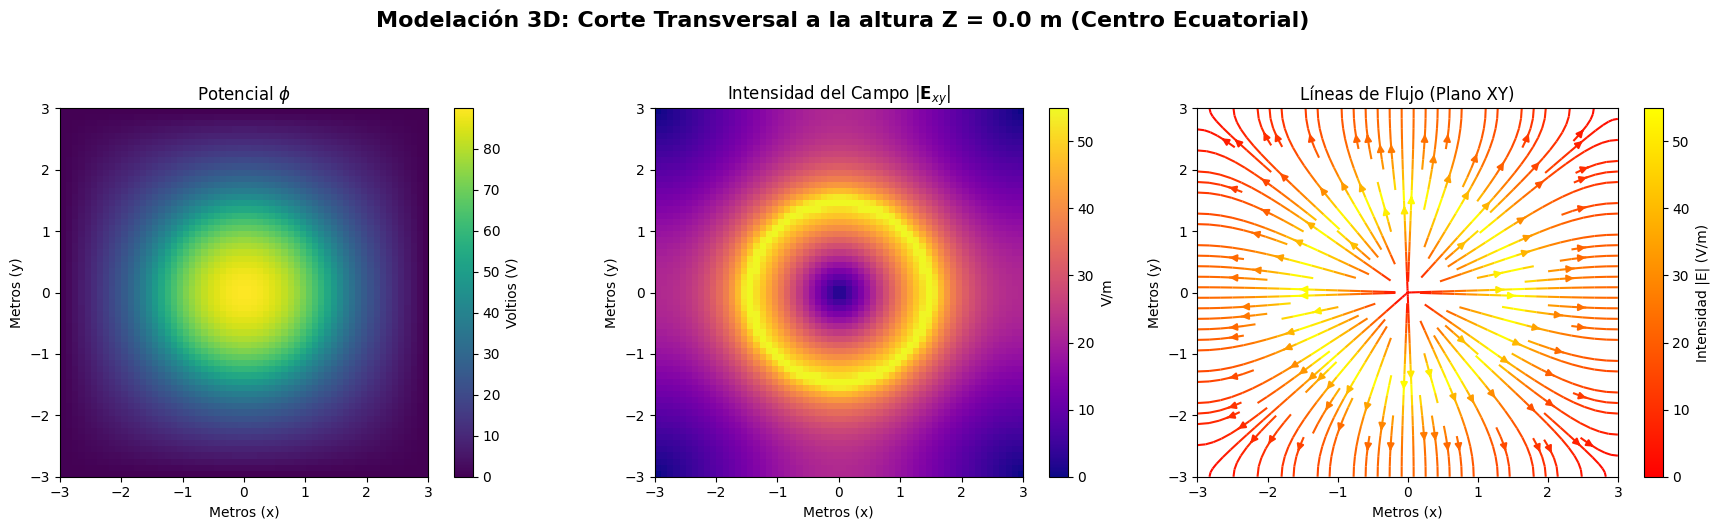

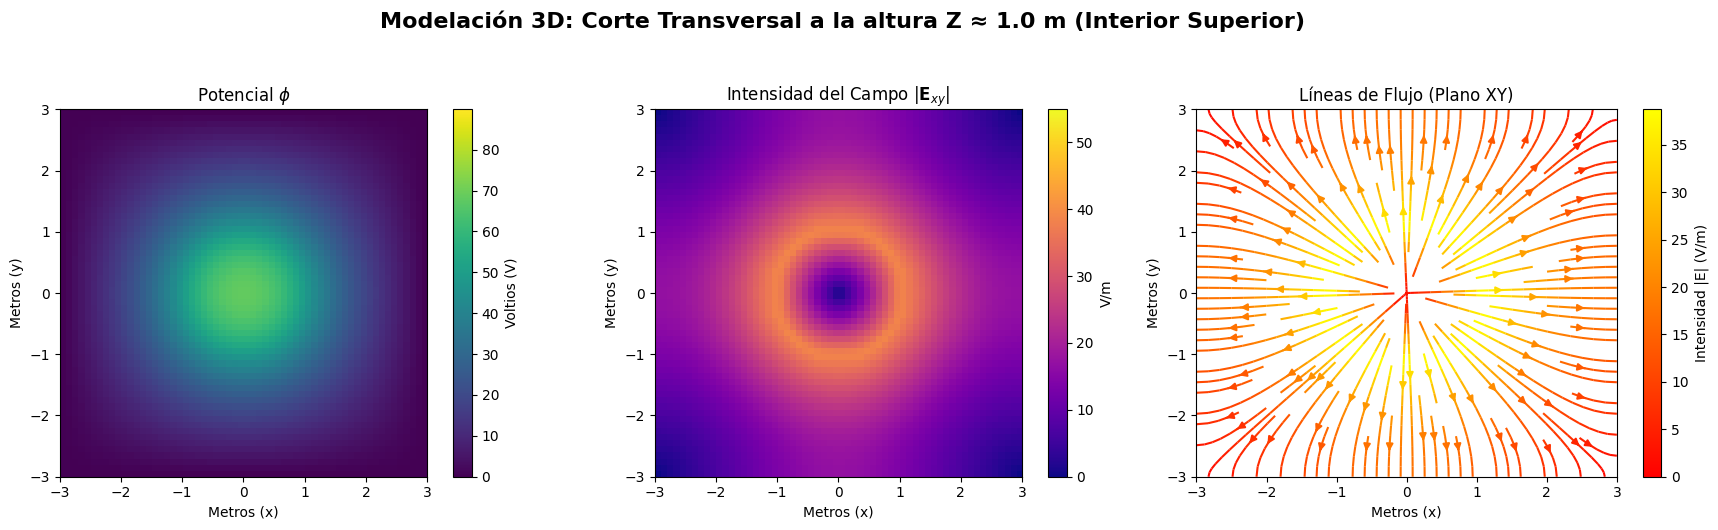

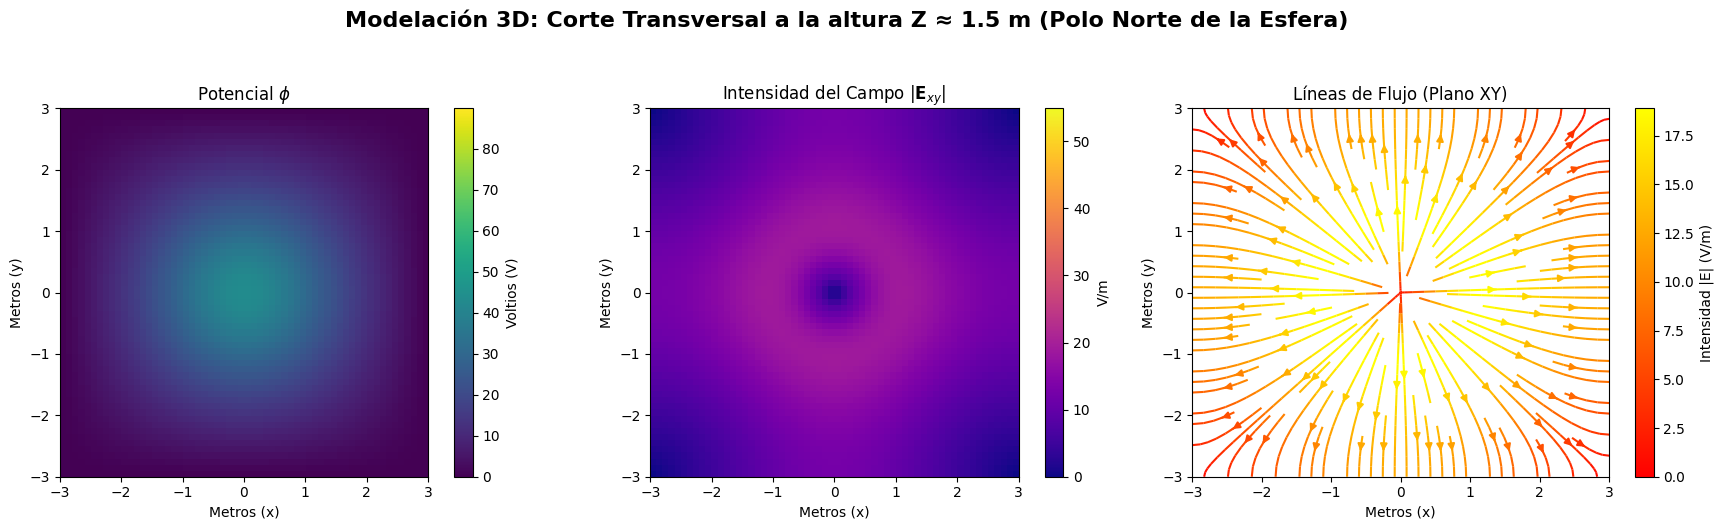

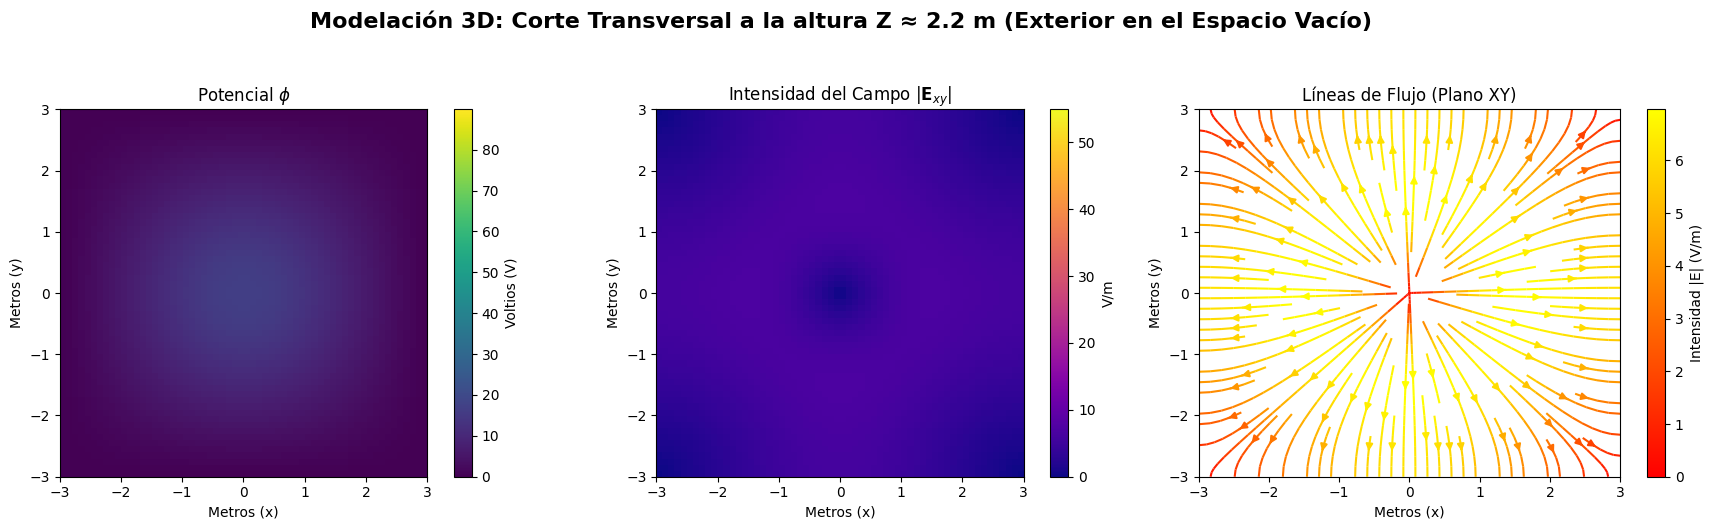

In [65]:
# Modelación 3D: Esfera Uniforme

import numpy as np
import matplotlib.pyplot as plt

# Configuración de la Malla 3D
metros = 5 
Lx, Ly, Lz = 1.2 * metros, 1.2 * metros, 1.2 * metros 

# Reducimos la resolución porque O(N^3) consume mucha memoria RAM
Mx, My, Mz = 60, 60, 60 
dx = Lx / (Mx - 1)
dy = Ly / (My - 1)
dz = Lz / (Mz - 1)
h = dx # Asumimos dx = dy = dz
e_0 = 8.8541878128e-12

# Arreglos 1D
x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
z = np.linspace(-Lz/2, Lz/2, Mz)

# Malla 3D (Cubo de datos)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Distancia radial 3D (Teorema de Pitágoras en 3 ejes)
R_3d = np.sqrt(X**2 + Y**2 + Z**2)

# Geometría 3D: Esfera Sólida
rho_3d = np.zeros((Mx, My, Mz))
Q0 = 1e-9 # Carga constante
radio_esfera = 1.5 

mask_esfera = (R_3d <= radio_esfera)
rho_3d[mask_esfera] = Q0

# Resolución Numérica 3D (SOR Rojo-Negro)
phi_3d = np.zeros((Mx, My, Mz))
omega = 1.9
tolerancia = 1e-5
error_sor = 1.0
iteraciones_sor = 0

# Máscaras 3D
I, J, K = np.indices(phi_3d.shape)
interior = np.zeros_like(phi_3d, dtype=bool)
interior[1:-1, 1:-1, 1:-1] = True # Protegemos todas las "paredes" del cubo

mask_rojo = interior & ((I + J + K) % 2 == 0)
mask_negro = interior & ((I + J + K) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < 5000:
    phi_old = phi_3d.copy()
    
    # Actualización ROJAS en 3D (Factor de 1/6 en lugar de 1/4)
    promedio = np.zeros_like(phi_3d)
    promedio[1:-1, 1:-1, 1:-1] = (1.0/6.0) * (
        phi_3d[2:, 1:-1, 1:-1] + phi_3d[:-2, 1:-1, 1:-1] + 
        phi_3d[1:-1, 2:, 1:-1] + phi_3d[1:-1, :-2, 1:-1] + 
        phi_3d[1:-1, 1:-1, 2:] + phi_3d[1:-1, 1:-1, :-2] + 
        (h**2 * rho_3d[1:-1, 1:-1, 1:-1] / e_0)
    )
    phi_3d[mask_rojo] = (1 - omega) * phi_3d[mask_rojo] + omega * promedio[mask_rojo]
    
    # Actualización NEGRAS en 3D
    promedio[1:-1, 1:-1, 1:-1] = (1.0/6.0) * (
        phi_3d[2:, 1:-1, 1:-1] + phi_3d[:-2, 1:-1, 1:-1] + 
        phi_3d[1:-1, 2:, 1:-1] + phi_3d[1:-1, :-2, 1:-1] + 
        phi_3d[1:-1, 1:-1, 2:] + phi_3d[1:-1, 1:-1, :-2] + 
        (h**2 * rho_3d[1:-1, 1:-1, 1:-1] / e_0)
    )
    phi_3d[mask_negro] = (1 - omega) * phi_3d[mask_negro] + omega * promedio[mask_negro]
    
    error_sor = np.max(np.abs(phi_3d - phi_old))
    iteraciones_sor += 1

# Cálculo del Campo Vectorial 3D
Ex, Ey, Ez = np.gradient(-phi_3d, dx, dy, dz)

# Visualización: Múltiples Cortes Transversales (Slicing)

# Calculamos algunos índices representativos a lo largo del eje Z
mid_z = Mz // 2         # Z = 0.0 m (Centro exacto ecuatorial)
cuarto_z = mid_z + 10   # Z ≈ 1.0 m (Corte superior dentro de la esfera)
borde_z = mid_z + 15    # Z ≈ 1.5 m (Justo en el "Polo Norte" de la esfera)
afuera_z = mid_z + 22   # Z ≈ 2.2 m (Flotando en el espacio, fuera de la esfera)

# Creamos una lista con los cortes que queremos analizar
cortes_a_visualizar = [
    (mid_z, "Z = 0.0 m (Centro Ecuatorial)"),
    (cuarto_z, "Z ≈ 1.0 m (Interior Superior)"),
    (borde_z, "Z ≈ 1.5 m (Polo Norte de la Esfera)"),
    (afuera_z, "Z ≈ 2.2 m (Exterior en el Espacio Vacío)")
]

# Buscamos el valor máximo global del potencial y del campo en todo el cubo 3D 
# para mantener la misma escala de colores en todas las fotos.
max_phi_global = np.max(phi_3d)
max_E_global = np.max(np.sqrt(Ex**2 + Ey**2))

for indice_z, titulo_corte in cortes_a_visualizar:
    
    # Extraemos las rebanadas en 2D y aplicamos la Transpuesta (.T) para Matplotlib
    phi_slice = phi_3d[:, :, indice_z].T
    Ex_slice = Ex[:, :, indice_z].T
    Ey_slice = Ey[:, :, indice_z].T
    X_slice = X[:, :, indice_z].T
    Y_slice = Y[:, :, indice_z].T
    
    # Magnitud del campo eléctrico proyectado en este plano 2D (solo Ex y Ey)
    E_mag_slice = np.sqrt(Ex_slice**2 + Ey_slice**2)
    
    # Generamos los 3 paneles
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Modelación 3D: Corte Transversal a la altura {titulo_corte}", 
                 fontsize=16, fontweight='bold', y=1.05)

    # Panel 1: Mapa del Potencial Escalar
    im0 = ax[0].imshow(phi_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='viridis', vmin=0, vmax=max_phi_global)
    ax[0].set_title(r"Potencial $\phi$")
    ax[0].set_xlabel('Metros (x)')
    ax[0].set_ylabel('Metros (y)')
    plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

    # Panel 2: Mapa de Intensidad del Campo Eléctrico
    im1 = ax[1].imshow(E_mag_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='plasma', vmin=0, vmax=max_E_global)
    ax[1].set_title(r"Intensidad del Campo $|\mathbf{E}_{xy}|$")
    ax[1].set_xlabel('Metros (x)')
    ax[1].set_ylabel('Metros (y)')
    plt.colorbar(im1, ax=ax[1], label='V/m')

    # Panel 3: Líneas de flujo del campo eléctrico
    # Solo mostramos flechas si hay algo de campo, de lo contrario streamplot podría quejarse
    if np.max(E_mag_slice) > 1e-6:
        st = ax[2].streamplot(X_slice, Y_slice, Ex_slice, Ey_slice, color=E_mag_slice, 
                              cmap='autumn', density=1.2, linewidth=1.5)
        fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')
    
    ax[2].set_title("Líneas de Flujo (Plano XY)")
    ax[2].set_xlabel('Metros (x)')
    ax[2].set_ylabel('Metros (y)')
    ax[2].set_xlim([-Lx/2, Lx/2])
    ax[2].set_ylim([-Ly/2, Ly/2])

    plt.tight_layout()
    plt.show()
plt.show()

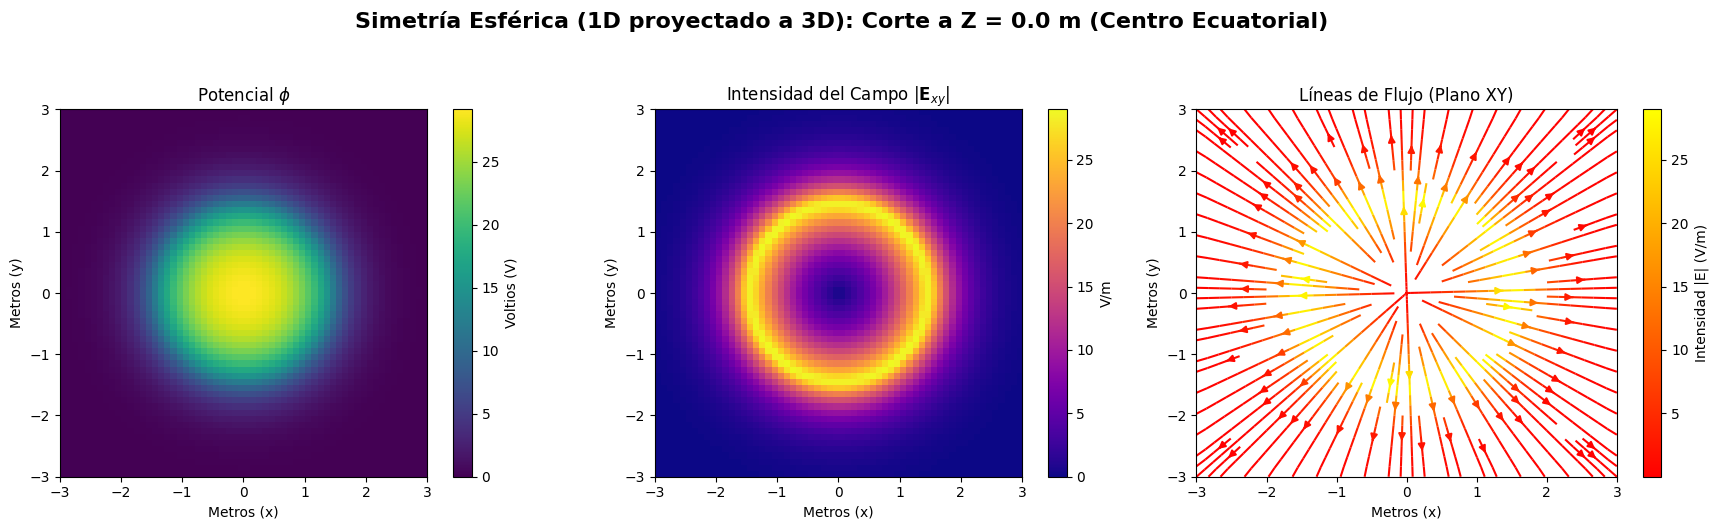

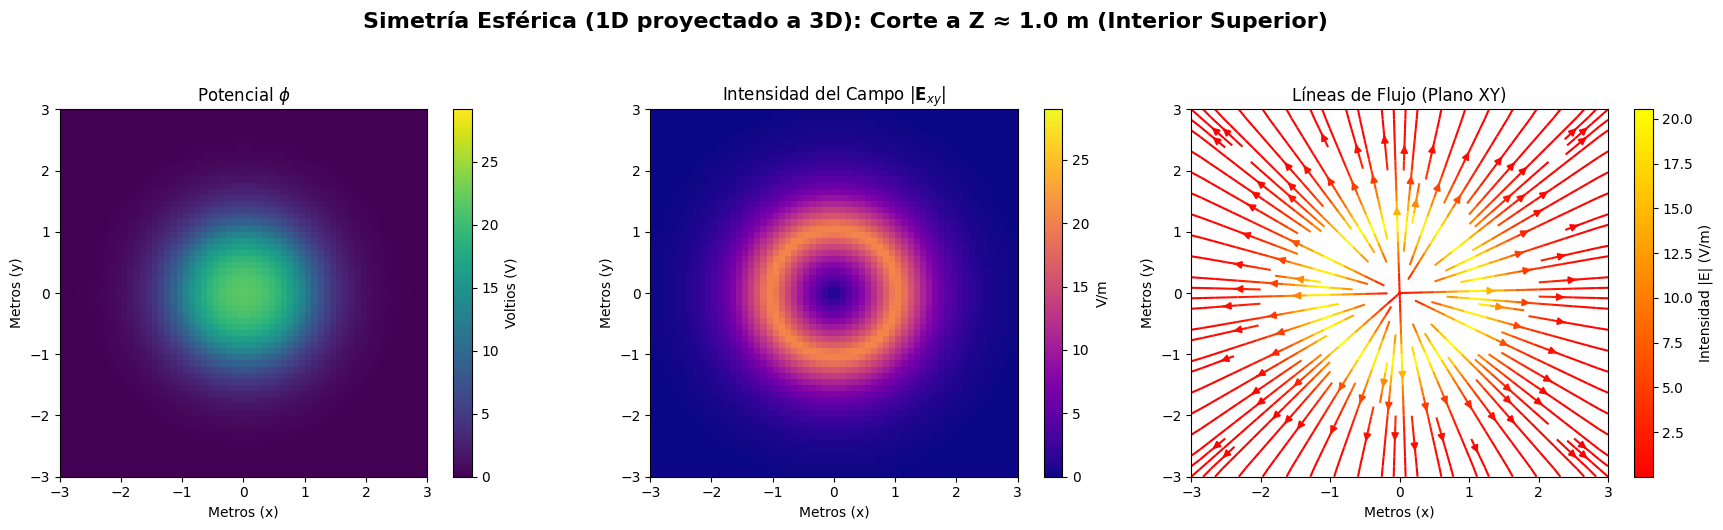

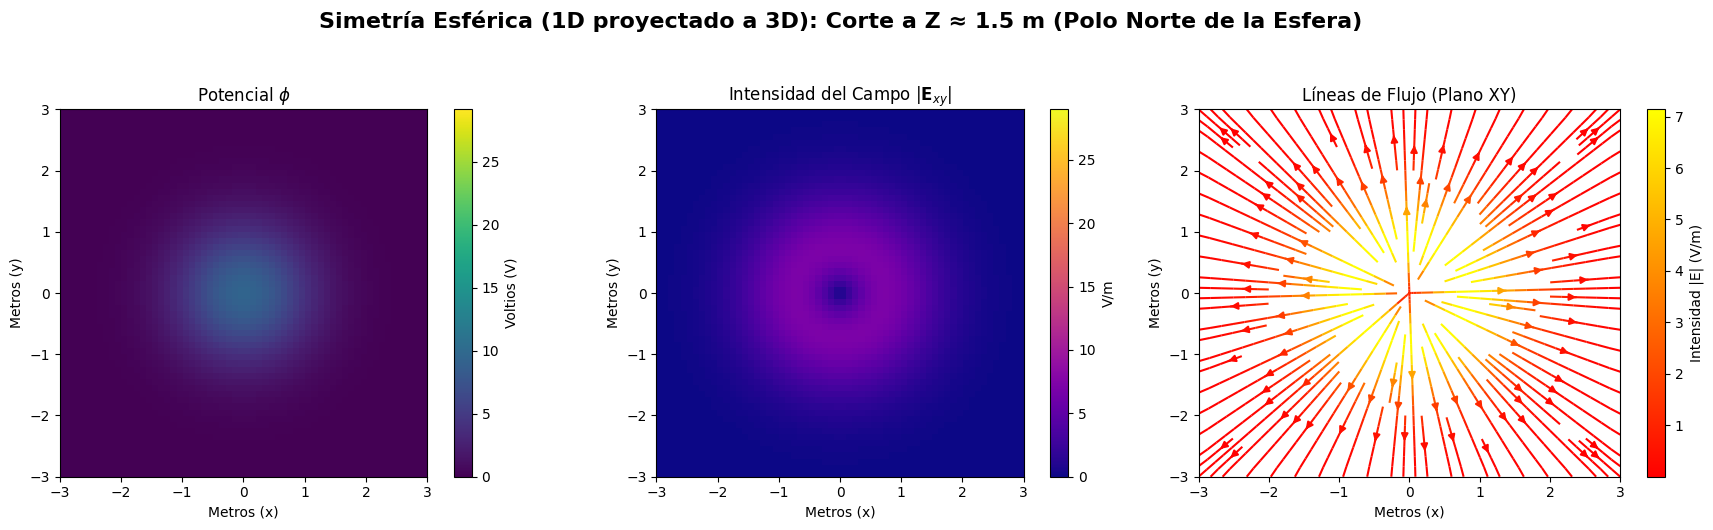

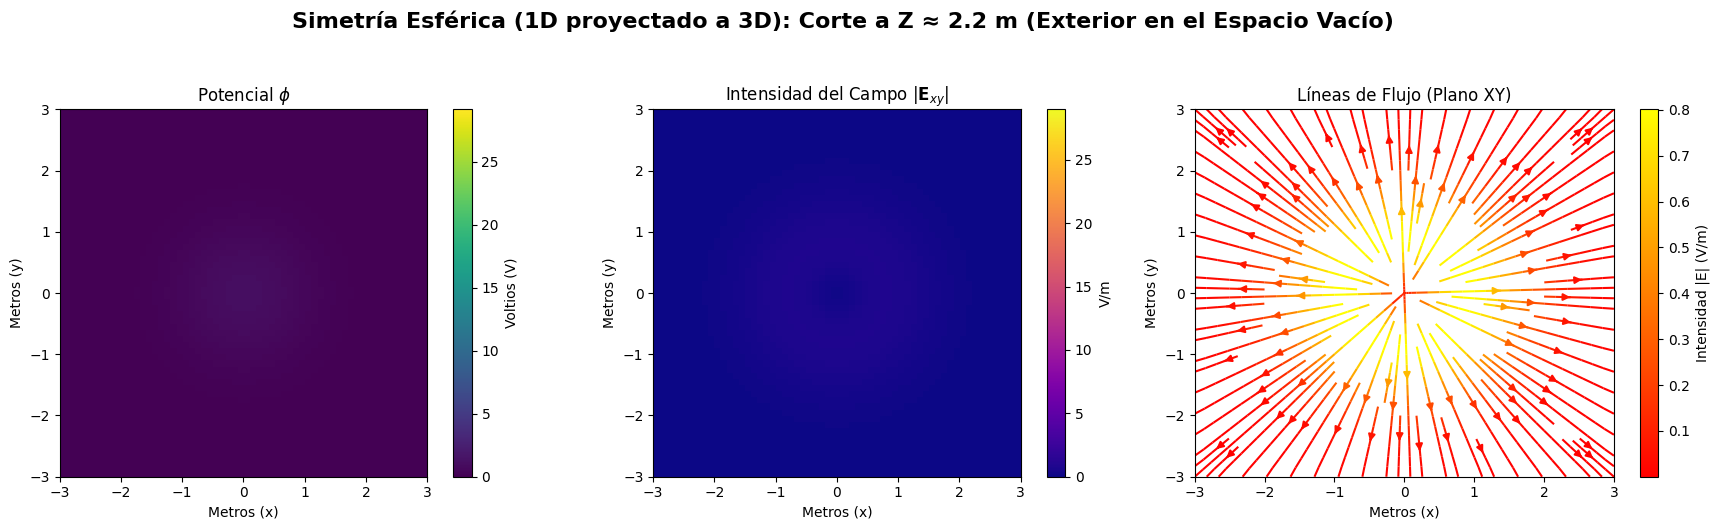

¡Proyección esférica 1D -> 3D calculada exitosamente!


In [66]:
# 10. Resolución en Coordenadas Esféricas 1D y Proyección a 3D
import numpy as np
import matplotlib.pyplot as plt

# Malla Cartesiana 3D de Referencia
metros = 5 
Lx, Ly, Lz = 1.2 * metros, 1.2 * metros, 1.2 * metros 
Mx, My, Mz = 60, 60, 60  
dx, dy, dz = Lx/(Mx-1), Ly/(My-1), Lz/(Mz-1)
e_0 = 8.8541878128e-12
Q0 = 1e-9
radio_esfera = 1.5 

x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
z = np.linspace(-Lz/2, Lz/2, Mz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Calculamos el radio exacto de cada punto en el espacio 3D
R_3d = np.sqrt(X**2 + Y**2 + Z**2)


# SOLUCIÓN EN COORDENADAS ESFÉRICAS (1D)
Nr = 1000 # Usamos 1000 puntos solo para el radio (resolución altísima)
r_max = np.max(R_3d) + 0.1 
r_esferico = np.linspace(0, r_max, Nr)
dr = r_esferico[1] - r_esferico[0]

# Densidad 1D
rho_1d = np.zeros(Nr)
rho_1d[r_esferico <= radio_esfera] = Q0

# Iteración vectorizada en 1D para U(r)
U = np.zeros(Nr)
for iteracion in range(20000):
    U_old = U.copy()
    U[1:-1] = 0.5 * (U[2:] + U[:-2] + (dr**2 * r_esferico[1:-1] * rho_1d[1:-1]) / e_0)
    U[-1] = 0 # Condición de frontera (phi=0 en el infinito)
    
    if np.max(np.abs(U - U_old)) < 1e-7:
        break

# Recuperamos phi(r) = U(r)/r
phi_esferica_1d = np.zeros(Nr)
phi_esferica_1d[1:] = U[1:] / r_esferico[1:]
phi_esferica_1d[0] = phi_esferica_1d[1] # El centro exacto


# PROYECCIÓN DE 1D A 3D
# Usamos interpolación para asignar el valor de phi a cada punto del cubo 3D según su radio
phi_3d_esferica = np.interp(R_3d, r_esferico, phi_esferica_1d)

# Calculamos el Campo Vectorial en la nueva matriz 3D
Ex, Ey, Ez = np.gradient(-phi_3d_esferica, dx, dy, dz)


# VISUALIZACIÓN DE LOS CORTES
mid_z = Mz // 2         # Z = 0.0 m
cuarto_z = mid_z + 10   # Z ≈ 1.0 m
borde_z = mid_z + 15    # Z ≈ 1.5 m
afuera_z = mid_z + 22   # Z ≈ 2.2 m

cortes_a_visualizar = [
    (mid_z, "Z = 0.0 m (Centro Ecuatorial)"),
    (cuarto_z, "Z ≈ 1.0 m (Interior Superior)"),
    (borde_z, "Z ≈ 1.5 m (Polo Norte de la Esfera)"),
    (afuera_z, "Z ≈ 2.2 m (Exterior en el Espacio Vacío)")
]

max_phi_global = np.max(phi_3d_esferica)
# Proyectamos la magnitud del campo sobre el plano XY para la visualización
max_E_global = np.max(np.sqrt(Ex**2 + Ey**2)) 

for indice_z, titulo_corte in cortes_a_visualizar:
    
    # Extraemos las rebanadas y transponemos para Matplotlib
    phi_slice = phi_3d_esferica[:, :, indice_z].T
    Ex_slice = Ex[:, :, indice_z].T
    Ey_slice = Ey[:, :, indice_z].T
    X_slice = X[:, :, indice_z].T
    Y_slice = Y[:, :, indice_z].T
    
    E_mag_slice = np.sqrt(Ex_slice**2 + Ey_slice**2)
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Simetría Esférica (1D proyectado a 3D): Corte a {titulo_corte}", 
                 fontsize=16, fontweight='bold', y=1.05)

    # Panel 1
    im0 = ax[0].imshow(phi_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='viridis', vmin=0, vmax=max_phi_global)
    ax[0].set_title(r"Potencial $\phi$")
    ax[0].set_xlabel('Metros (x)')
    ax[0].set_ylabel('Metros (y)')
    plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

    # Panel 2
    im1 = ax[1].imshow(E_mag_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='plasma', vmin=0, vmax=max_E_global)
    ax[1].set_title(r"Intensidad del Campo $|\mathbf{E}_{xy}|$")
    ax[1].set_xlabel('Metros (x)')
    ax[1].set_ylabel('Metros (y)')
    plt.colorbar(im1, ax=ax[1], label='V/m')

    # Panel 3
    if np.max(E_mag_slice) > 1e-6:
        st = ax[2].streamplot(X_slice, Y_slice, Ex_slice, Ey_slice, color=E_mag_slice, 
                              cmap='autumn', density=1.2, linewidth=1.5)
        fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')
    
    ax[2].set_title("Líneas de Flujo (Plano XY)")
    ax[2].set_xlabel('Metros (x)')
    ax[2].set_ylabel('Metros (y)')
    ax[2].set_xlim([-Lx/2, Lx/2])
    ax[2].set_ylim([-Ly/2, Ly/2])

    plt.tight_layout()
    plt.show()

print("¡Proyección esférica 1D -> 3D calculada exitosamente!")